In [13]:
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [32]:
df = pd.read_csv("wildfire_multi_region_dataset.csv")

df.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,satellite,instrument,brightness_k,frp_mw,fire_intensity,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
0,-16.7722,151.0241,2024-01-01,1133,2024,1,Summer,D,Australia,Australia,...,TERRA,MODIS,347.72,29.38,Moderate,high,42.1,1.7,0.47,18.4
1,-41.1960,130.1397,2024-01-01,1251,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,357.82,62.05,High,nominal,43.8,2.2,0.27,11.7
2,-39.8750,124.9104,2024-01-02,1326,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,333.76,3.35,Low,high,35.4,4.4,0.35,5.0
3,-10.0978,149.8371,2024-01-02,206,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,323.94,46.35,Moderate,high,39.6,34.7,0.30,39.1
4,-12.4540,119.2301,2024-01-02,2054,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,359.59,434.80,Extreme,high,46.7,16.7,6.49,53.1


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15500 entries, 0 to 15499
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        15500 non-null  float64
 1   longitude       15500 non-null  float64
 2   acq_date        15500 non-null  object 
 3   acq_time        15500 non-null  int64  
 4   year            15500 non-null  int64  
 5   month           15500 non-null  int64  
 6   season          15500 non-null  object 
 7   daynight        15500 non-null  object 
 8   region          15500 non-null  object 
 9   country         15500 non-null  object 
 10  fire_type       15500 non-null  object 
 11  satellite       15500 non-null  object 
 12  instrument      15500 non-null  object 
 13  brightness_k    15500 non-null  float64
 14  frp_mw          15500 non-null  float64
 15  fire_intensity  15500 non-null  object 
 16  confidence      15500 non-null  object 
 17  temp_max_c      15500 non-null 

In [16]:
df.isnull().sum()

latitude          0
longitude         0
acq_date          0
acq_time          0
year              0
month             0
season            0
daynight          0
region            0
country           0
fire_type         0
satellite         0
instrument        0
brightness_k      0
frp_mw            0
fire_intensity    0
confidence        0
temp_max_c        0
wind_max_kmh      0
precip_mm         0
humidity_pct      0
dtype: int64

In [17]:
df.describe()

,latitude,longitude,acq_time,year,month,brightness_k,frp_mw,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
count,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000,15500.000000
mean,10.251489,29.204768,1177.268645,2024.503032,7.244774,336.501241,80.181982,35.099335,17.783774,2.595579,38.136716
std,24.367098,78.693275,689.540417,0.500007,2.768195,19.209340,150.411669,5.850954,17.617369,3.154769,18.890952
min,-42.990800,-167.990600,0.000000,2024.000000,1.000000,290.000000,0.370000,12.800000,0.000000,0.000000,5.000000
25%,-7.561575,-41.641000,600.000000,2024.000000,5.000000,324.570000,15.010000,31.000000,5.100000,0.610000,24.300000
50%,10.477350,34.807950,1200.000000,2025.000000,8.000000,335.170000,35.445000,35.200000,12.500000,1.520000,36.300000
75%,30.104450,95.064200,1756.000000,2025.000000,9.000000,346.670000,83.720000,39.200000,24.700000,3.330000,50.800000
max,69.982600,153.987500,2359.000000,2025.000000,12.000000,574.860000,3000.000000,55.500000,188.800000,34.440000,95.000000


In [18]:
df.shape

(15500, 21)

In [21]:
df["fire_intensity"].unique()

array(['Moderate', 'High', 'Low', 'Extreme'], dtype=object)

In [25]:
# Variables a escoger con las que voy a trabajar 
# Temperatura maxima, velocidad del viento maxima y precipitación.

variables = df[["temp_max_c", "wind_max_kmh", "precip_mm"]]

variables.head()



,temp_max_c,wind_max_kmh,precip_mm
0,42.1,1.7,0.47
1,43.8,2.2,0.27
2,35.4,4.4,0.35
3,39.6,34.7,0.30
4,46.7,16.7,6.49


  fire_intensity  count
0       Moderate   6861
1           High   4785
2            Low   2493
3        Extreme   1361


<Axes: xlabel='fire_intensity'>

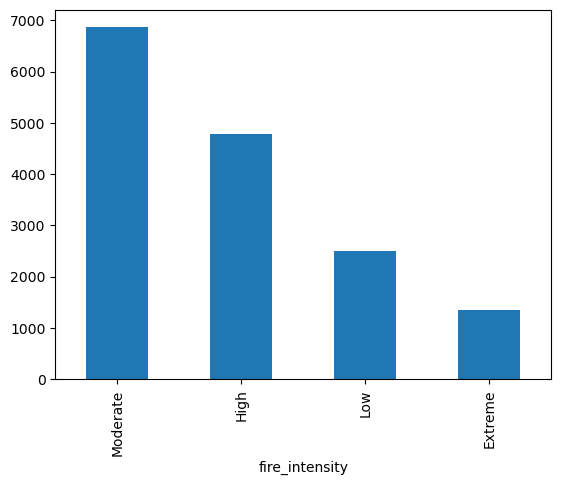

In [29]:
#Se observa un fuerte desbalance de clases. Esto implica que la Matriz de Confusión podría mostrar una alta precisión en la clase 'Low', pero debemos vigilar de cerca la clase 'Extreme',
#ya que el modelo tendrá menos ejemplos para aprender a identificarla
tabla_distribucion = df['fire_intensity'].value_counts().reset_index()
print(tabla_distribucion)
df['fire_intensity'].value_counts().plot(kind='bar')

In [ ]:
columnas_categoricas = ['region', 'tipo_de_incendio', 'estacion']

# Aplicamos One-Hot Encoding
df_final = pd.get_dummies(df, columns=columnas_categoricas)

In [31]:
df.shape

(15500, 4)

In [ ]:
X = variables
y = df['fire_intensity'].to_frame()